# 🖼️ DeepSphericalStitcher — 360° Panorama Image Stitching

## 📌 What does this notebook do?
This notebook takes **multiple overlapping images** (e.g., taken from a rotating camera)
and stitches them together into a **single wide / 360° panorama image**.

## 📁 Files / Images Required
| Requirement | Details |
|---|---|
| **Input folder** | A folder named `data` in the **same directory as this notebook** |
| **Image formats** | `.jpg`, `.jpeg`, `.png` |
| **Minimum images** | At least **2** images (ideally 5–30 overlapping shots) |
| **Image overlap** | Each consecutive image should share **~30–50% overlap** with the next |
| **Camera tip** | Keep the camera at the same height; rotate horizontally for best results |

## 🗂️ Folder Structure
```
your_project/
│
├── deep_stitch.ipynb   ← This notebook
│
└── data/               ← Put ALL your images inside this folder
    ├── img_001.jpg
    ├── img_002.jpg
    └── img_003.jpg
```

## 🚀 Output
- A stitched panorama saved as **`proper_360_stitch.jpg`** in the same folder as this notebook.

---

## ⚙️ Step 0 — Install Required Library (Run Once)
If you haven't installed OpenCV yet, run the cell below **once**.
After installation, you can skip this cell in future runs.

In [2]:
# Run this cell ONCE to install OpenCV if it's not already installed.
# opencv-contrib-python includes extra modules like SIFT.
# You can comment this cell out after the first run.
import sys
!{sys.executable} -m pip install opencv-contrib-python --quiet
print('✅ OpenCV installed / already present.')

✅ OpenCV installed / already present.


'C:\Users\vicky\Anaconda' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
# ============================================================
# CELL 1 — Import Required Libraries
# ============================================================

# opencv-python (cv2): Core computer vision library.
#   Used for reading images, resizing, colour conversion,
#   feature detection (SIFT), and the Stitcher class.
import cv2

# numpy: Numerical Python — images in OpenCV are stored as
#   NumPy arrays of shape (height, width, channels).
import numpy as np

# os: Operating System module — used to list files in a
#   folder and build full file paths.
import os

# matplotlib: Used to display images inline inside Jupyter.
#   (We do NOT use cv2.imshow() because it opens a separate
#    window; matplotlib shows images right inside the notebook.)
import matplotlib.pyplot as plt

# IPython display helper — lets us show images in Jupyter cells
from IPython.display import display, Image as IPImage

print('✅ All libraries imported successfully!')
print(f'   OpenCV version : {cv2.__version__}')
print(f'   NumPy  version : {np.__version__}')


✅ All libraries imported successfully!
   OpenCV version : 4.12.0
   NumPy  version : 2.2.6


In [4]:
# ============================================================
# CELL 2 — Helper: Display an Image Inside Jupyter
# ============================================================
# OpenCV reads images in BGR (Blue-Green-Red) colour order.
# Matplotlib expects RGB (Red-Green-Blue) order.
# So we must convert BGR → RGB before plotting.

def show_image(img, title='Image', figsize=(14, 6)):
    """
    Display a single OpenCV image (BGR) inline in Jupyter.

    Parameters:
        img     : NumPy array — the image to display (BGR format)
        title   : string      — title shown above the image
        figsize : tuple       — (width, height) of the display in inches
    """
    # Convert BGR (OpenCV default) → RGB (Matplotlib default)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Create a figure of the specified size
    plt.figure(figsize=figsize)

    # imshow() displays the image; we turn off axis ticks for a clean look
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

print('✅ Helper function show_image() ready.')


✅ Helper function show_image() ready.


In [5]:
# ============================================================
# CELL 3 — Define the DeepSphericalStitcher Class
# ============================================================
# A 'class' is a blueprint that bundles related data and
# functions together. This class handles the full pipeline:
#   1. Load & pre-process images from a folder
#   2. Stitch using OpenCV's built-in Stitcher
#   3. Auto-crop the black borders
#   4. Display and save the final panorama

class DeepSphericalStitcher:
    """
    Creates a 360° panorama from multiple overlapping images.

    High-level pipeline:
    ────────────────────
    1. Load all .jpg/.png images from a folder.
    2. Resize them uniformly (faster processing).
    3. Apply CLAHE to fix uneven brightness across images.
    4. Use OpenCV Stitcher (PANORAMA mode) which:
         a. Detects key-points (SIFT features) in each image.
         b. Matches key-points between overlapping images.
         c. Runs Bundle Adjustment to find best camera angles.
         d. Warps images onto a spherical surface.
         e. Blends seams smoothly.
    5. Crop the irregular black border produced by warping.
    6. Display and save the result.
    """

    # ------------------------------------------------------------------
    # __init__ — Constructor: runs automatically when you do
    #            pipeline = DeepSphericalStitcher('data')
    #
    # Parameters:
    #   folder_path  — path to the folder containing your images
    #   resize_width — all images are resized to this width (pixels).
    #                  600 is a good balance of speed vs quality.
    # ------------------------------------------------------------------
    def __init__(self, folder_path, resize_width=600):
        self.folder_path  = folder_path
        self.resize_width = resize_width

        # Load and pre-process all images immediately
        self.images = self._prepare_data()

        # SIFT = Scale-Invariant Feature Transform.
        # Finds distinctive 'key-points' (corners, blobs) in images.
        # These are used internally by the Stitcher to match images.
        self.finder = cv2.SIFT_create()

    # ------------------------------------------------------------------
    # _prepare_data — Private helper to load and enhance images.
    # The underscore prefix (_) is a Python convention meaning
    # 'this method is for internal use only'.
    # ------------------------------------------------------------------
    def _prepare_data(self):
        """
        Reads every image file from the folder, resizes it, and
        applies CLAHE brightness normalisation.
        Returns a list of processed BGR images (NumPy arrays).
        """

        # List all image files in the folder, sorted by filename.
        # Sorting ensures left-to-right ordering (img_001 before img_002).
        files = sorted([
            f for f in os.listdir(self.folder_path)
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))
        ])

        # Warn the user if the folder is empty or path is wrong
        if len(files) == 0:
            print(f"❌ No images found in '{self.folder_path}'.")
            print("   Check the folder name and make sure images are inside it.")
            return []

        print(f"📂 Found {len(files)} image(s):")
        for f in files:
            print(f"   - {f}")

        processed = []   # Collect successfully processed images here

        for f in files:
            # Build the full path, e.g., 'data/img_001.jpg'
            full_path = os.path.join(self.folder_path, f)

            # cv2.imread() reads the image as a NumPy array (BGR colour).
            # Returns None if the file is missing or corrupted.
            img = cv2.imread(full_path)

            if img is None:
                print(f"   ⚠️  Could not read '{f}' — skipping.")
                continue

            # ── Resize ──────────────────────────────────────────────────
            # Keep the original aspect ratio (height proportional to width)
            # while forcing the width to self.resize_width.
            h, w = img.shape[:2]              # img.shape = (height, width, channels)
            new_h = int(h * (self.resize_width / w))   # Scale height proportionally
            img = cv2.resize(img, (self.resize_width, new_h))

            # ── CLAHE (Contrast Limited Adaptive Histogram Equalization) ─
            #
            # WHY we need it:
            #   Photos taken at different times/angles often have different
            #   brightness levels. Stitching a bright image next to a dark
            #   one produces harsh seams. CLAHE normalises local brightness
            #   to make the transition smooth.
            #
            # HOW it works:
            #   Step A — Convert BGR → LAB colour space.
            #     LAB splits an image into:
            #       L  = Lightness (brightness) channel
            #       A  = Green–Red colour axis
            #       B  = Blue–Yellow colour axis
            #     We only touch 'L' so colours are preserved.
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)    # Split into 3 separate single-channel arrays

            #   Step B — Create CLAHE object.
            #     clipLimit=2.0      : max amplification; prevents over-brightening
            #                          noisy/smooth regions.
            #     tileGridSize=(8,8) : image divided into 8×8 tile grid;
            #                          equalization applied per tile (local, not global).
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

            #   Step C — Apply CLAHE only to the L (brightness) channel
            l = clahe.apply(l)

            #   Step D — Merge the enhanced L back with original A and B
            img = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

            processed.append(img)

        print(f"\n✅ Pre-processed {len(processed)} images for Spherical Stitching.")
        return processed

    # ------------------------------------------------------------------
    # run_proper_stitch — Main method: stitch all images into a panorama.
    # ------------------------------------------------------------------
    def run_proper_stitch(self):
        """
        Uses OpenCV's Stitcher (PANORAMA mode) to produce a panorama.

        Internally, Stitcher performs:
          1. Feature Detection  — finds key-points in each image (SIFT)
          2. Feature Matching   — matches key-points across image pairs
          3. Bundle Adjustment  — optimises ALL camera poses simultaneously
          4. Spherical Warping  — maps each image onto a sphere surface
          5. Blending           — merges images smoothly at the seams
        """

        # Guard: abort if no images were loaded
        if not self.images:
            print('❌ No images available. Check your folder path.')
            return

        # ── Create the Stitcher ──────────────────────────────────────────
        # cv2.Stitcher_PANORAMA → Spherical projection.
        #   Best for wide-angle / 360° shots (camera rotating in place).
        # cv2.Stitcher_SCANS    → Affine (flat) projection.
        #   Best for document scans placed side by side.
        stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

        print(f'🚀 Starting Bundle Adjustment for {len(self.images)} images...')
        print('   (May take 1–3 minutes depending on image count and size)')

        # ── Stitch! ──────────────────────────────────────────────────────
        # Returns a tuple: (status_code, panorama_image)
        #   status == 0  → cv2.Stitcher_OK  (success)
        #   status == 1  → ERR_NEED_MORE_IMGS
        #   status == 2  → ERR_HOMOGRAPHY_EST_FAIL
        #   status == 3  → ERR_CAMERA_PARAMS_ADJUST_FAIL
        status, panorama = stitcher.stitch(self.images)

        if status == cv2.Stitcher_OK:
            # Remove irregular black borders created by spherical warping
            final_result = self.auto_crop(panorama)

            print('\n✨ Stitching Successful!')
            print(f'   Final size: {final_result.shape[1]}W × {final_result.shape[0]}H pixels')

            # Display the panorama inline in Jupyter
            show_image(final_result, title='✅ Final 360° Panorama')

            # Save to disk in the current working directory
            output_path = 'proper_360_stitch.jpg'
            cv2.imwrite(output_path, final_result)
            print(f'💾 Saved as: {os.path.abspath(output_path)}')

        else:
            print(f'\n❌ Stitching failed with Status Code: {status}')
            self._explain_error(status)

    # ------------------------------------------------------------------
    # auto_crop — Removes the black border after spherical warping.
    # ------------------------------------------------------------------
    def auto_crop(self, img):
        """
        After spherical warping, the panorama has an irregular black
        curved border. This method trims it cleanly.

        Steps:
          1. Convert to greyscale (simpler to process).
          2. Threshold → binary mask: content=white (255), border=black (0).
          3. Find contours (outlines of white regions).
          4. Find bounding rectangle of the largest contour.
          5. Crop to that rectangle.
        """

        # Convert colour image (3 channels) to greyscale (1 channel)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Threshold: pixel value > 1 → 255 (white), else 0 (black)
        # This separates the real image content from pure black borders
        # cv2.threshold() returns (threshold_used, result_image)
        thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)[1]

        # findContours detects outlines of white regions
        # RETR_EXTERNAL  → only the outermost outlines (ignore inner holes)
        # CHAIN_APPROX_SIMPLE → store only corner points (memory efficient)
        cnts = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

        if cnts:
            # The largest contour by area = the main image content
            c = max(cnts, key=cv2.contourArea)

            # boundingRect gives the smallest rectangle that fits the contour
            # Returns (x, y, width, height) — x,y is the top-left corner
            x, y, w, h = cv2.boundingRect(c)

            # Crop using NumPy array slicing: img[rows, cols]
            return img[y:y + h, x:x + w]

        return img  # Return unchanged if no contours found

    # ------------------------------------------------------------------
    # _explain_error — Maps status codes to human-readable messages.
    # ------------------------------------------------------------------
    def _explain_error(self, status):
        """Prints a clear explanation and fix suggestion for each error code."""
        errors = {
            1: (
                'ERR_NEED_MORE_IMGS — Not enough overlapping images.\n'
                '   💡 Fix: Add more images; ensure 30-50% overlap between consecutive shots.'
            ),
            2: (
                'ERR_HOMOGRAPHY_EST_FAIL — Could not find matching feature points.\n'
                '   💡 Fix: Images may be too dark, blurry, or featureless.\n'
                '          Use well-lit, sharp photos of textured scenes.'
            ),
            3: (
                'ERR_CAMERA_PARAMS_ADJUST_FAIL — Camera geometry mismatch.\n'
                '   💡 Fix: All images should be from the same camera.\n'
                '          Rotate the camera in place; do not move it sideways.'
            ),
        }
        print('   Reason:', errors.get(status, f'Unknown error code: {status}'))


print("✅ Class 'DeepSphericalStitcher' defined successfully!")
print('   Run the next cell to start stitching.')


✅ Class 'DeepSphericalStitcher' defined successfully!
   Run the next cell to start stitching.


📂 Found 30 image(s):
   - 1.jpeg
   - 10.jpeg
   - 11.jpeg
   - 12.jpeg
   - 13.jpeg
   - 14.jpeg
   - 15.jpeg
   - 16.jpeg
   - 17.jpeg
   - 18.jpeg
   - 19.jpeg
   - 2.jpeg
   - 20.jpeg
   - 21.jpeg
   - 22.jpeg
   - 23.jpeg
   - 24.jpeg
   - 25.jpeg
   - 26.jpeg
   - 27.jpeg
   - 28.jpeg
   - 29.jpeg
   - 3.jpeg
   - 30.jpeg
   - 4.jpeg
   - 5.jpeg
   - 6.jpeg
   - 7.jpeg
   - 8.jpeg
   - 9.jpeg

✅ Pre-processed 30 images for Spherical Stitching.


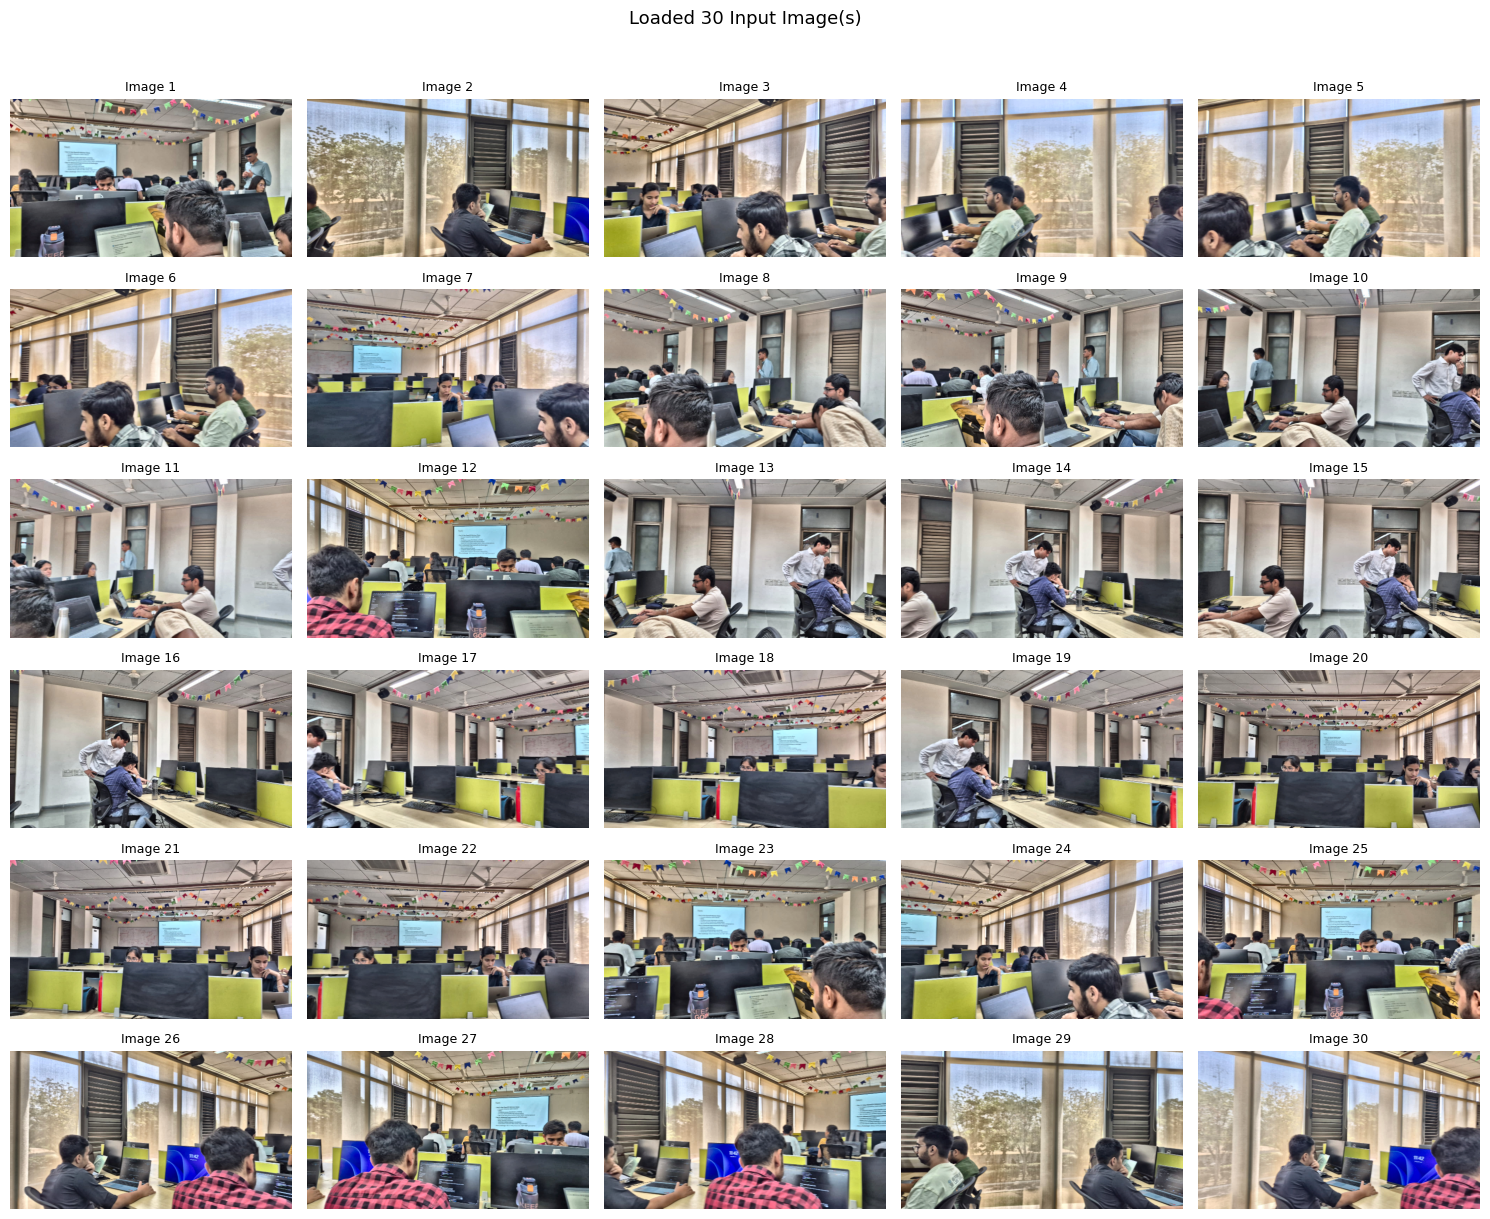


👆 Verify these are the correct images, then run the next cell.


In [6]:
# ============================================================
# CELL 4 — (Optional) Preview Your Input Images
# ============================================================
# This cell shows you a small thumbnail of every loaded image
# so you can verify the correct images were loaded before stitching.

IMAGE_FOLDER = 'data'    # ← Change this if your folder has a different name
RESIZE_WIDTH = 600       # ← Width each image is resized to (pixels)

# Create the stitcher object — this also loads and pre-processes images
pipeline = DeepSphericalStitcher(IMAGE_FOLDER, resize_width=RESIZE_WIDTH)

# Show a preview grid of all loaded images
if pipeline.images:
    n = len(pipeline.images)
    cols = min(n, 5)                          # Max 5 images per row
    rows = (n + cols - 1) // cols             # How many rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2))
    axes = np.array(axes).flatten()           # Flatten to 1D for easy looping

    for i, img in enumerate(pipeline.images):
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f'Image {i+1}', fontsize=9)
        axes[i].axis('off')

    # Hide any unused subplot slots
    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Loaded {n} Input Image(s)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    print('\n👆 Verify these are the correct images, then run the next cell.')
else:
    print('No images loaded — check your folder path above.')


  Running Panorama Stitching...
🚀 Starting Bundle Adjustment for 30 images...
   (May take 1–3 minutes depending on image count and size)

✨ Stitching Successful!
   Final size: 2739W × 340H pixels


C:\Users\vicky\AppData\Local\Temp\ipykernel_6432\4137785365.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vicky\Anaconda 2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


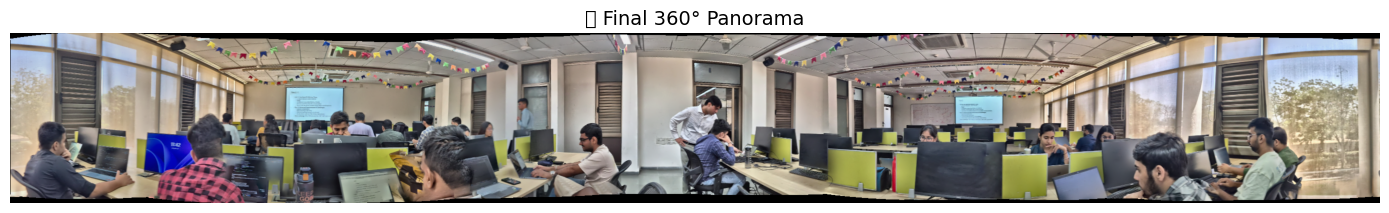

💾 Saved as: C:\Users\vicky\Desktop\CV\CV29\proper_360_stitch.jpg


In [7]:
# ============================================================
# CELL 5 — Run the Stitching Pipeline
# ============================================================
# Calling run_proper_stitch() on the already-loaded pipeline:
#   - Detects features (SIFT key-points)
#   - Matches features across images
#   - Runs Bundle Adjustment (globally optimises camera angles)
#   - Warps + blends images into a panorama
#   - Auto-crops black borders
#   - Displays and saves the result

print('=' * 55)
print('  Running Panorama Stitching...')
print('=' * 55)

pipeline.run_proper_stitch()


---
## 🛠️ Troubleshooting Guide

| Problem | Likely Cause | Solution |
|---|---|---|
| `ERR_NEED_MORE_IMGS` | Too few / non-overlapping images | Add more images; ensure 30–50% overlap |
| `ERR_HOMOGRAPHY_EST_FAIL` | Dark / blurry / featureless images | Use well-lit, sharp, textured photos |
| `ERR_CAMERA_PARAMS_ADJUST_FAIL` | Mixed cameras or sideways movement | Keep camera fixed; rotate horizontally only |
| Seam lines visible | Different exposure levels | CLAHE handles this; try `clipLimit=1.0` |
| Very slow processing | Images too large | Reduce `RESIZE_WIDTH` to `400` |
| Black borders in output | Normal after spherical warp | `auto_crop()` handles this automatically |
| `cv2.error` on SIFT | Missing contrib module | Run: `pip install opencv-contrib-python` |

---
## 💡 Key Concepts Glossary

| Term | Plain English |
|---|---|
| **SIFT** | Finds 'interesting' corners/blobs in images for matching |
| **Key-point** | A distinctive pixel location (corner, edge) used to match images |
| **CLAHE** | Brightness normalisation tile-by-tile — fixes dark/bright patches |
| **Bundle Adjustment** | Maths that optimises ALL camera angles simultaneously |
| **Spherical Warping** | Maps flat images onto a sphere surface for 360° panoramas |
| **Homography** | A 3×3 matrix that maps one image plane to another |
| **Contour** | The outline boundary of an object in a binary image |
| **BGR vs RGB** | OpenCV uses Blue-Green-Red; Matplotlib expects Red-Green-Blue |
